In [2]:
# Standard imports — same ones used throughout L13 and L14
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import requests

In [3]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

C:\Users\andre\AppData\Local\Temp\ipykernel_19544\3291602058.py:7: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [4]:
data

array([['GRB260421C*', 'GRB260421B', 'GRB260421A', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['GRB260421351', 'GRB260421176', 'GRB260421092', ..., 'None',
        'None', 'None'],
       ['8:25:18.055', '4:13:21', '2:12:44', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['19.2000', '18.1510', '1.5410', ..., '3.1360', '208.5760',
        '5.6960'],
       ['True', 'False', 'True', ..., 'False', 'False', 'False'],
       ['61151.35090341', '61151.17593750', '61151.09217593', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      shape=(15, 9086), dtype='<U14')

In [5]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [7]:
t90_idx = np.where(names == 'T90')[0][0]
t90_idx

np.int64(6)

In [8]:
fluence_idx = np.where(names == 'fluence')[0][0]
fluence_idx

np.int64(9)

In [9]:
def fast_float(arr):
    arr = np.asanyarray(arr, dtype=str)
    clean_arr = np.where((arr == 'null') | (arr == '') | (arr == 'None'), 'nan', arr)
    return clean_arr.astype(float)

In [12]:
T90 = fast_float(data[t90_idx])
print(len(T90))

9086


In [13]:
fluence = fast_float(data[fluence_idx])
print(len(fluence))

9086


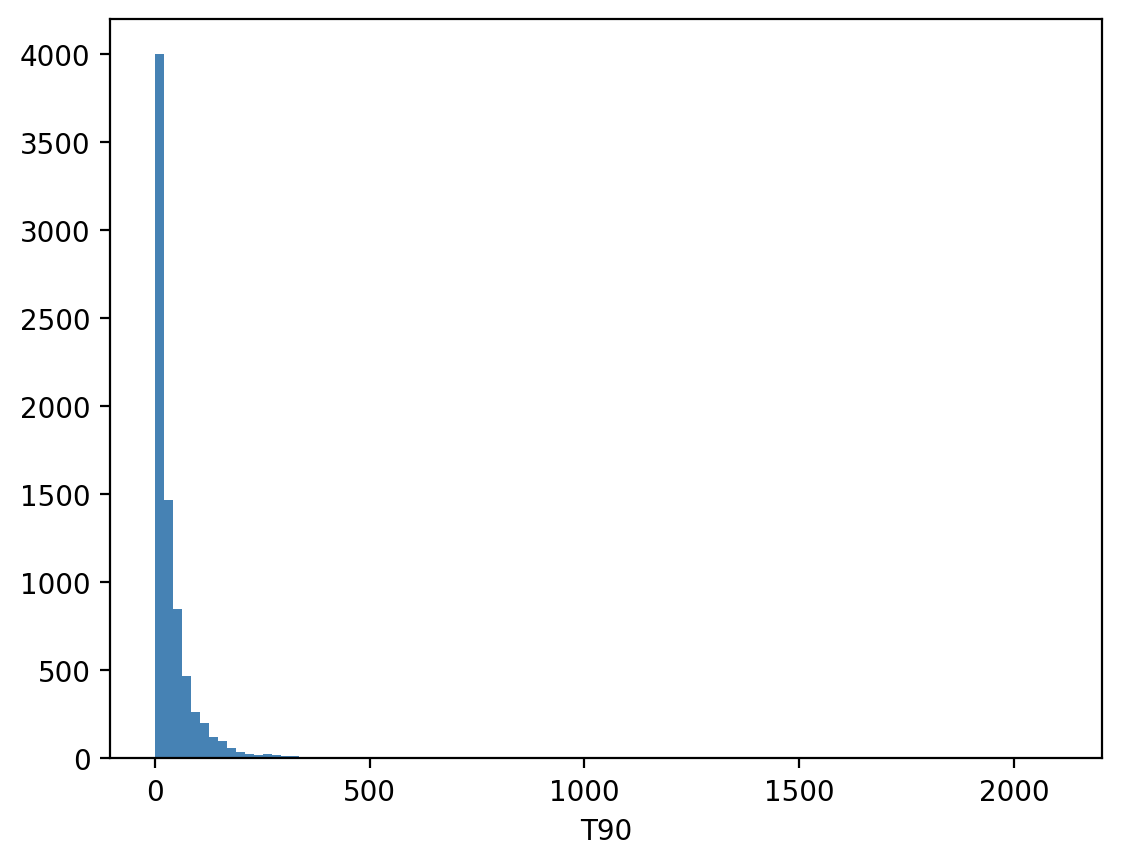

In [20]:
plt.hist(T90, bins=100, color='steelblue')
plt.xlabel('T90')
plt.show()

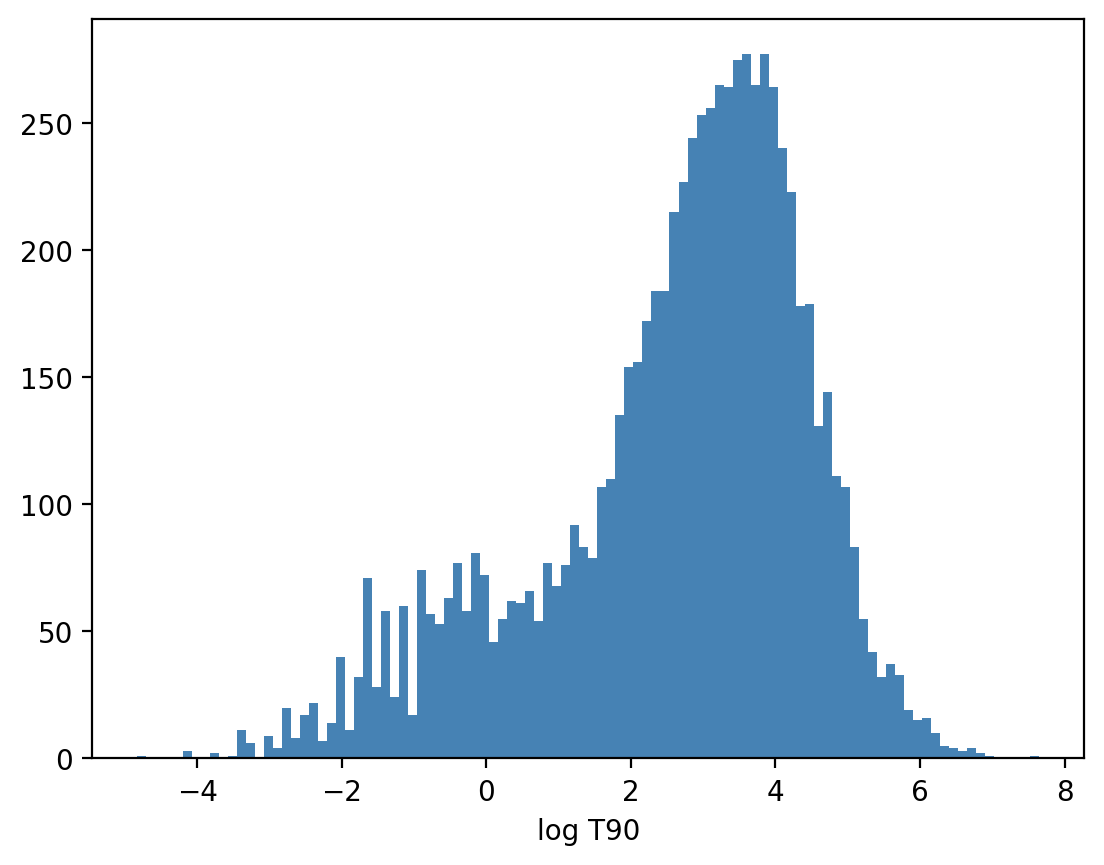

In [23]:
logT90 = np.log(T90)
plt.hist(logT90, bins=100, color='steelblue')
plt.xlabel('log T90')
plt.show()

In [21]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

In [24]:
bw_grid = np.linspace(0.02, 0.4, 30)
grid    = GridSearchCV(KernelDensity(), {'bandwidth': bw_grid}, cv=5)
grid.fit(logT90[:, np.newaxis])  
bw_best = grid.best_params_['bandwidth']
bw_best

np.float64(0.2820689655172414)

In [25]:
x_grid   = np.linspace(logT90.min() - 0.5, logT90.max() + 0.5, 500)
kde      = KernelDensity(bandwidth=bw_best).fit(logT90[:, np.newaxis])
log_dens = kde.score_samples(x_grid[:, np.newaxis])

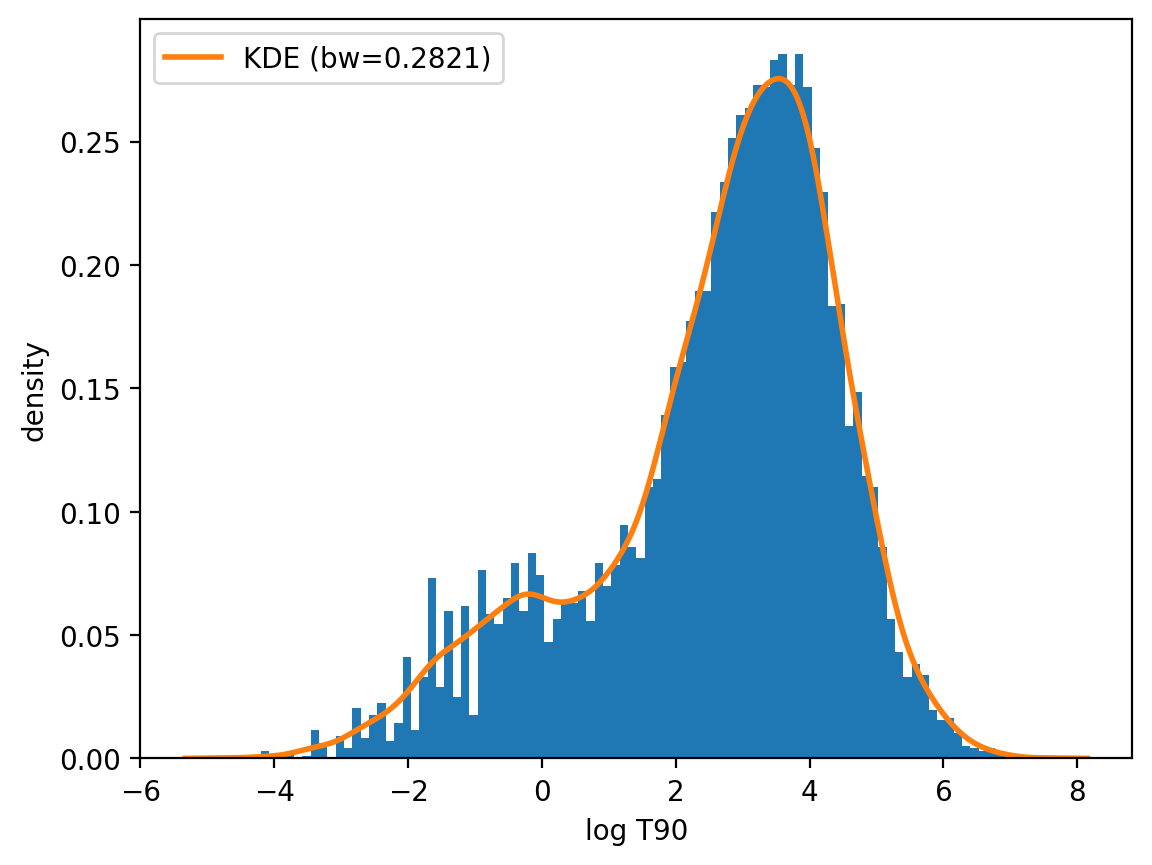

In [27]:
plt.hist(logT90, bins=100, density=True)
plt.plot(x_grid, np.exp(log_dens), 'C1', linewidth=2, label=f'KDE (bw={bw_best:.4f})')
plt.xlabel('log T90')
plt.ylabel('density')
plt.legend()
plt.show()

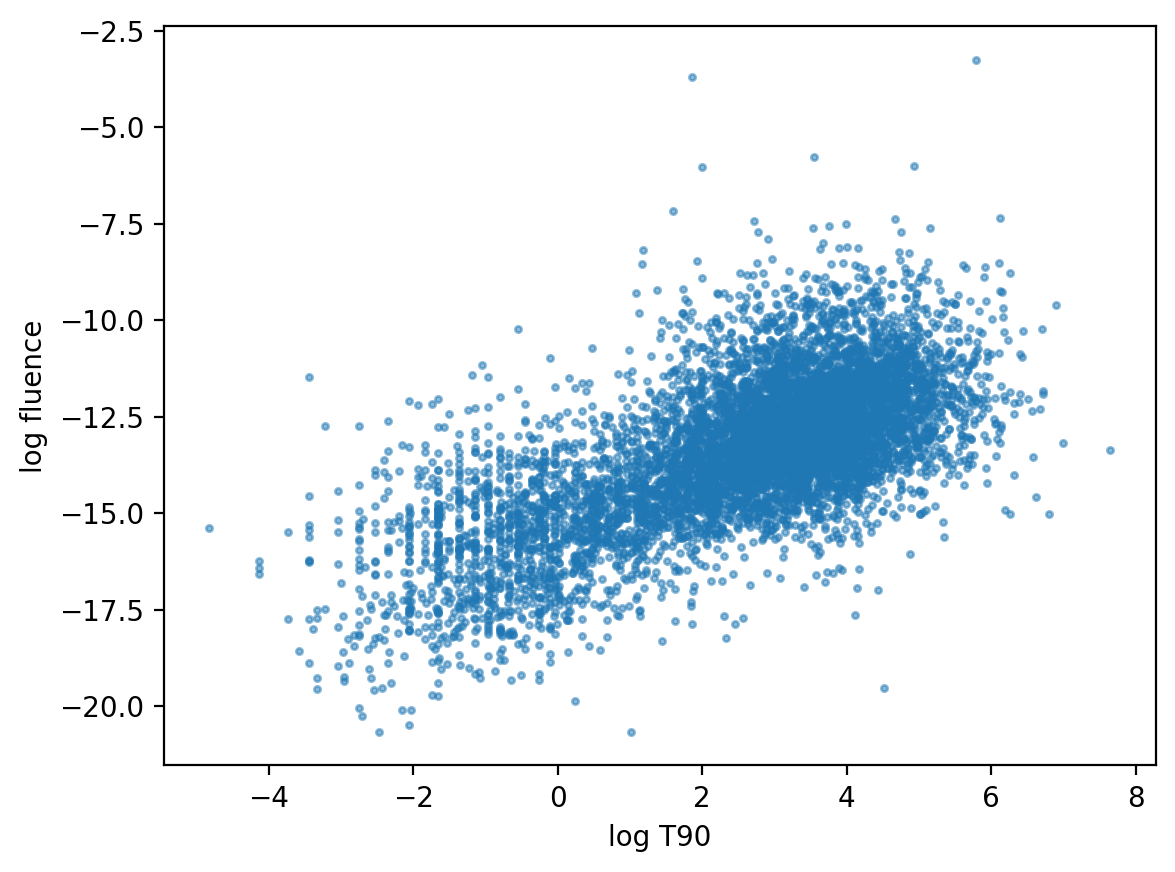

In [30]:
logFluence = np.log(Fluence)

plt.scatter(logT90, logFluence, s=5, alpha=0.5)
plt.xlabel('log T90')
plt.ylabel('log fluence')
plt.show()

In [31]:
X = np.column_stack([logT90, logFluence])

from sklearn import preprocessing
scaler   = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(1, 8)

for k in k_values:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_) 

In [42]:
km = KMeans(n_clusters=2, n_init='auto', random_state=42)
km.fit(X_scaled)
labels_km = km.predict(X_scaled)  

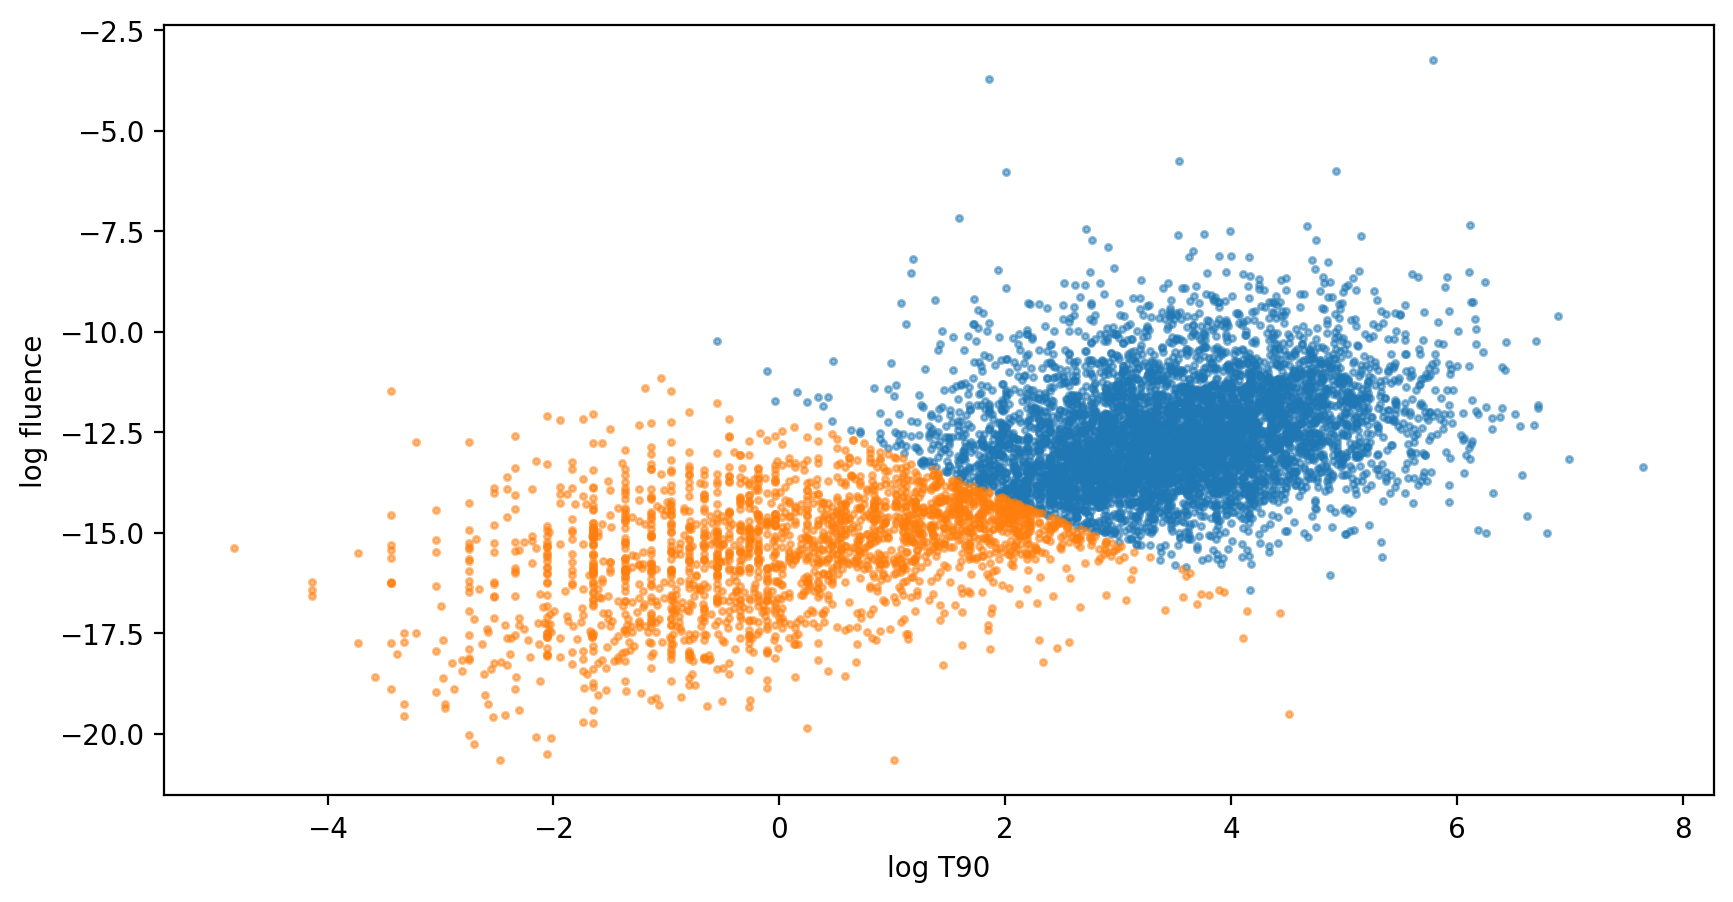

In [45]:
plt.figure(figsize=(10,5))
for k in range(2):
    mask = labels_km == k
    plt.scatter(X[mask,0], X[mask,1], s=5, alpha=0.5)
plt.xlabel('log T90')
plt.ylabel('log fluence')
plt.show()

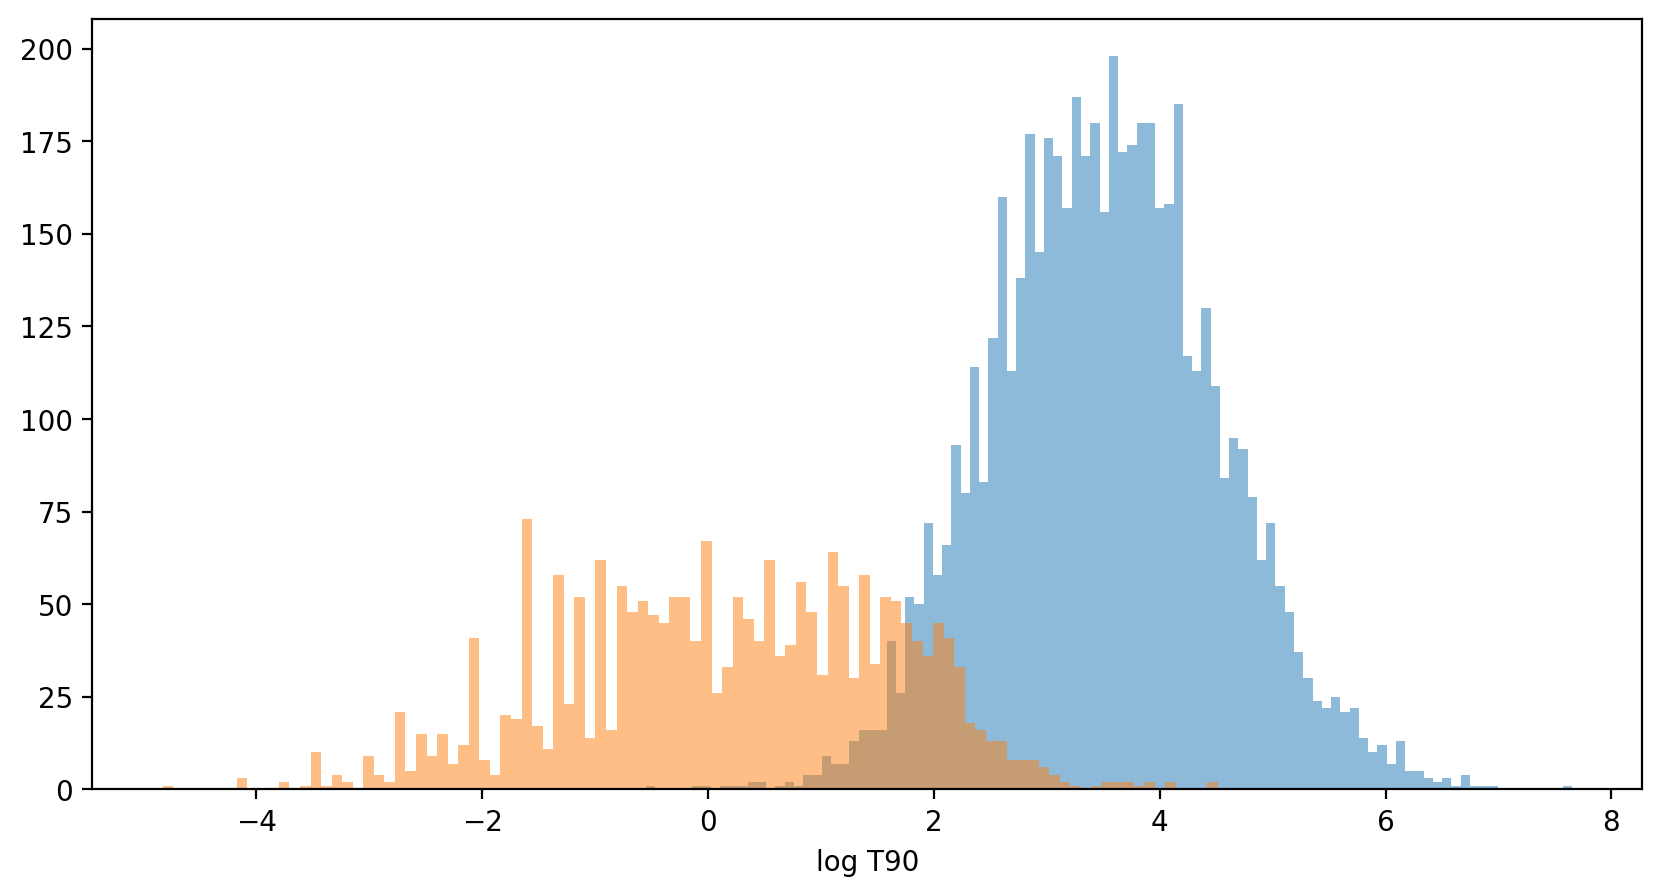

In [52]:
plt.figure(figsize=(10,5))
for k in range(2):
    mask = labels_km == k
    plt.hist(X[mask, 0], bins=100, alpha=0.5)
plt.xlabel('log T90')
plt.show()

In [ ]:
# Confusion-matrix style check — same idea as the confusion matrix in L13
# Compare K-Means labels against the classic 2 s threshold
from sklearn.metrics import confusion_matrix

# 'Reference' using the classic literature threshold (T90 = 2 s)
classic = (logT90 >= np.log10(2)).astype(int)  # 0 = short, 1 = long

# K-Means may swap cluster 0 and 1 — align them by comparing centroid T90
if centers[0, 0] > centers[1, 0]:  # cluster 0 has the larger T90 => it is the long one
    labels_aligned = 1 - labels_km  # flip so 0 = short, 1 = long
else:
    labels_aligned = labels_km

cm = confusion_matrix(classic, labels_aligned)
print('Confusion matrix (rows = classic label, cols = K-Means label):')
print(cm)
print('\nRows/cols: [short (T90<2s), long (T90>2s)]')

In [ ]:
# ---- MEAN-SHIFT CLUSTERING (from L14) ----
# Mean-shift does NOT require you to choose K in advance — it finds clusters automatically
# It works by finding the modes of the KDE, so bandwidth has the same meaning as before
from sklearn.cluster import MeanShift

# Try a few bandwidth values to see how sensitive the result is
for bw in [0.3, 0.5, 0.8]:
    ms_test = MeanShift(bandwidth=bw, bin_seeding=True)
    ms_test.fit(X_scaled)
    print(f'  bandwidth = {bw}  =>  {len(np.unique(ms_test.labels_))} clusters found')

In [ ]:
# Run Mean-Shift with bandwidth = 0.5 (a reasonable middle ground from the test above)
ms = MeanShift(bandwidth=0.5, bin_seeding=True)
ms.fit(X_scaled)
labels_ms     = ms.labels_
n_clusters_ms = len(np.unique(labels_ms))

print('Number of clusters found by Mean-Shift:', n_clusters_ms)

centers_ms = scaler.inverse_transform(ms.cluster_centers_)
print('Mean-Shift cluster centres [log10 scale]:')
for i, c in enumerate(centers_ms):
    print(f'  Cluster {i}: log10(T90) = {c[0]:.2f}  =>  T90 ~ {10**c[0]:.1f} s')

In [ ]:
# Compare K-Means and Mean-Shift side by side — same plot style as L14
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means panel
for k in range(2):
    mask = labels_km == k
    axes[0].scatter(X[mask, 0], X[mask, 1], s=4, alpha=0.4, label=f'Cluster {k}')
axes[0].scatter(centers[:, 0], centers[:, 1], marker='*', s=200, c='black')
axes[0].set_xlabel('log10(T90 / s)')
axes[0].set_ylabel('log10(Fluence)')
axes[0].set_title('K-Means (K=2)')
axes[0].legend(fontsize=8)

# Mean-Shift panel
for k in range(n_clusters_ms):
    mask = labels_ms == k
    axes[1].scatter(X[mask, 0], X[mask, 1], s=4, alpha=0.4, label=f'Cluster {k} (N={mask.sum()})')
axes[1].scatter(centers_ms[:, 0], centers_ms[:, 1], marker='*', s=200, c='black')
axes[1].set_xlabel('log10(T90 / s)')
axes[1].set_ylabel('log10(Fluence)')
axes[1].set_title(f'Mean-Shift ({n_clusters_ms} clusters)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Both methods broadly agree on the two main populations
# Mean-Shift may split the long GRBs further depending on the bandwidth

In [ ]:
# Outlier sensitivity: K-Means minimises squared distances so it is pulled by extremes
# Mean-Shift tracks density modes so isolated points do not shift anything

# Add 5 fake extreme outliers (very long duration, very low fluence)
np.random.seed(7)
outliers = np.column_stack([
    np.random.uniform(4.5, 5.5, 5),   # log10(T90) far outside normal range
    np.random.uniform(-10, -9,  5),   # log10(Fluence) far outside normal range
])
X_out        = np.vstack([X, outliers])
X_scaled_out = scaler.transform(X_out)  # use the same scaler, do not refit

# Re-run K-Means on the contaminated data
km_out      = KMeans(n_clusters=2, n_init='auto', random_state=42).fit(X_scaled_out)
centers_out = scaler.inverse_transform(km_out.cluster_centers_)

print('K-Means T90 centroids WITHOUT outliers:', [f'{10**c[0]:.1f} s' for c in centers])
print('K-Means T90 centroids WITH    outliers:', [f'{10**c[0]:.1f} s' for c in centers_out])

# The centroids shift noticeably — K-Means is NOT robust to outliers
# Mean-Shift would not create a large cluster around 5 isolated points

In [ ]:
# Final question: are all GRBs equally likely to be observed?
# Short GRBs are intrinsically brief AND tend to be fainter
# => the catalogue is likely biased against them (selection effect)

# Use the K-Means labels to separate short and long GRBs
short_cluster = np.argmin(centers[:, 0])  # cluster with the smaller T90 centroid
is_short = labels_km == short_cluster
is_long  = ~is_short

print(f'Short GRBs (K-Means): {is_short.sum()}')
print(f'Long  GRBs (K-Means): {is_long.sum()}')

# Compare the fluence distributions — short GRBs should appear fainter on average
plt.hist(logFluence[is_short], bins=40, alpha=0.6, density=True, label='Short GRBs')
plt.hist(logFluence[is_long],  bins=40, alpha=0.6, density=True, label='Long GRBs')
plt.xlabel('log10(Fluence)')
plt.ylabel('Density')
plt.title('Fluence distribution by class')
plt.legend()
plt.show()

# Short GRBs peak at lower fluence => they are fainter => harder to detect
# => we probably see fewer short GRBs than actually exist (flux-limited survey bias)

In [ ]:
# KS test to check whether the fluence difference is statistically significant
# Same idea as model comparison we discussed in L13
from scipy.stats import ks_2samp

D, p = ks_2samp(logFluence[is_short], logFluence[is_long])
print(f'KS test on log(Fluence):  D = {D:.3f},  p-value = {p:.2e}')
if p < 0.05:
    print('The two distributions are significantly different (p < 0.05)')
    print('=> Short GRBs are systematically fainter => selection bias is real')